# EDA: анализ данных химических соединений

Цель ноутбука -> провести разведочный анализ данных перед построением моделей машинного обучения.

В рамках анализа рассматриваются:

- размер и структура датасета
- типы признаков
- пропущенные значения
- дубликаты
- распределения целевых переменных `IC50, mM`, `CC50, mM`, `SI`
- распределения признаков
- корреляции между признаками и целевыми переменными
- потенциальные проблемы данных, выбросы, асимметрия распределений, утечка данных

## Импорты и настройки

In [193]:
# Библиотека для работы с предупреждениями
import warnings

# Библиотека для работы с путями к файлам и директориям
from pathlib import Path

# Библиотеки для работы с данными
import pandas as pd
import numpy as np

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Константы проекта: директория для графиков и названия целевых столбцов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.config import (
    FIGURES_DIR,
    TARGET_CC50,
    TARGET_IC50,
    TARGET_SI,
)

# Загрузка датасета и получение общей информации о данных
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.data_loader import (
    get_dataset_overview,
    load_coursework_dataset,
)

# Формирование признаков и получение списков признаковых/служебных столбцов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.preprocessing import (
    build_features,
    get_feature_columns,
    get_service_columns,
)

# Убираем шум по лишним предупреждениям
warnings.filterwarnings("ignore")

# Настраиваем отображение таблиц
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Настраиваем тему графиков
sns.set_theme(style="whitegrid")

# Создаем директорию для сохранения графиков, если она еще не существует
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Загрузка данных

In [194]:
df = load_coursework_dataset()
df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.2394,175.4824,28.1250,5.0941,5.0941,0.3872,0.3872,0.4174,42.9286,384.6520,340.3000,384.3504,158,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.7718,5.4028,7.0000,3.9614,3.9614,0.5339,0.5339,0.4625,45.2143,388.6840,340.3000,388.3817,162,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
2,2,223.8088,161.1423,0.7200,2.6271,2.6271,0.5432,0.5432,0.2609,42.1875,446.8080,388.3440,446.4589,186,0,...,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0
3,3,1.7056,107.8557,63.2353,5.0974,5.0974,0.3906,0.3906,0.3778,41.8621,398.6790,352.3110,398.3661,164,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0
4,4,107.1315,139.2710,1.3000,5.1505,5.1505,0.2705,0.2705,0.4290,36.5143,466.7130,424.3770,466.3348,184,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Базовая информация

In [195]:
overview = get_dataset_overview(df)
overview

{'rows': 1001, 'columns': 214, 'missing_values': 36, 'duplicated_rows': 0}

## Размерность данных

In [196]:
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")

service_columns = get_service_columns(df)
feature_columns = get_feature_columns(df)

print(f"Служебные столбцы: {service_columns}")
print(f"Количество признаков для моделей: {len(feature_columns)}")
print(f"Целевые столбцы: {[TARGET_IC50, TARGET_CC50, TARGET_SI]}")

Количество строк: 1001
Количество столбцов: 214
Служебные столбцы: ['Unnamed: 0']
Количество признаков для моделей: 210
Целевые столбцы: ['IC50, mM', 'CC50, mM', 'SI']


## Первичный обзор датасета

Исходный датасет содержит 1001 наблюдение и 214 столбцов.

Среди них:

- 3 целевых показателя: `IC50, mM`, `CC50, mM`, `SI`
- 1 служебный индексный столбец `Unnamed: 0`, который не является химическим признаком
- 210 числовых признаков, описывающих химические соединения

Полные дубликаты строк отсутствуют. В данных обнаружены пропущенные значения, которые необходимо дополнительно исследовать перед обучением моделей.

## Типы данных

In [197]:
dtype_summary = (
    df.dtypes
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="columns_count")
)

dtype_summary

,dtype,columns_count
0,int64,107
1,float64,107


## Проверка числовых признаков

In [198]:
non_numeric_columns = df.select_dtypes(exclude=["number"]).columns.tolist()

if non_numeric_columns:
    print("Нечисловые столбцы:")
    print(non_numeric_columns)
else:
    print("Все столбцы в датасете являются числовыми")

Все столбцы в датасете являются числовыми


## Первые статистики

In [199]:
df[[TARGET_IC50, TARGET_CC50, TARGET_SI]].describe().T

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",1001.0000,222.8052,402.1697,0.0035,12.5154,46.5852,224.9759,4128.5294
"CC50, mM",1001.0000,589.1107,642.8675,0.7008,99.9990,411.0393,894.0892,4538.9762
SI,1001.0000,72.5088,684.4827,0.0115,1.4333,3.8462,16.5667,15620.6000


## Промежуточный вывод по данным датасета

* Датасет содержит 1001 наблюдение и 214 столбцов
* Все столбцы числовые: 107 int64 и 107 float64
* Есть один служебный столбец: Unnamed: 0
* После исключения служебного столбца и целевых переменных остается 210 признаков для моделей
* Целевые переменные имеют сильный разброс и явные выбросы:
    * `IC50, mM`: максимум 4128.53, медиана 46.59
    * `CC50, mM`: максимум 4538.98, медиана 411.04
    * `SI`: максимум 15620.60, медиана 3.85

Примечание: у `SI` среднее 72.51, а медиана всего 3.85.
Предположительно, это связано с сильной правосторонней асимметрией из-за больших выбросов.

## Анализ пропущенных значений

На данном этапе проверим количество пропусков в датасете, определим признаки с пропущенными значениями и оценим их долю.

In [200]:
missing_summary = (
    df.isna()
    .sum()
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_percent"] = missing_summary["missing_count"] / len(df) * 100

missing_summary

,column,missing_count,missing_percent
0,MaxPartialCharge,3,0.2997
1,MinPartialCharge,3,0.2997
2,MaxAbsPartialCharge,3,0.2997
3,MinAbsPartialCharge,3,0.2997
4,BCUT2D_MWHI,3,0.2997
5,BCUT2D_MWLOW,3,0.2997
6,BCUT2D_CHGHI,3,0.2997
7,BCUT2D_CHGLO,3,0.2997
8,BCUT2D_LOGPHI,3,0.2997
9,BCUT2D_LOGPLOW,3,0.2997


In [201]:
print(f"Всего пропущенных значений: {df.isna().sum().sum()}")
print(f"Количество столбцов с пропусками: {missing_summary.shape[0]}")
print(f"Максимальная доля пропусков в одном столбце: {missing_summary['missing_percent'].max():.2f}%")

Всего пропущенных значений: 36
Количество столбцов с пропусками: 12
Максимальная доля пропусков в одном столбце: 0.30%


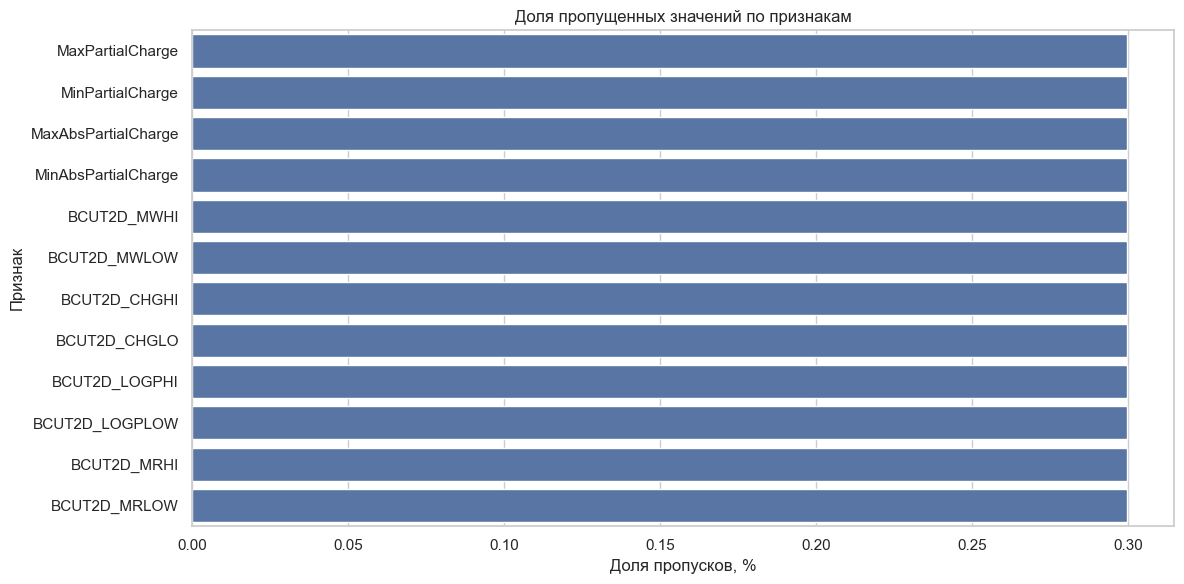

In [202]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=missing_summary,
    x="missing_percent",
    y="column",
)

plt.title("Доля пропущенных значений по признакам")
plt.xlabel("Доля пропусков, %")
plt.ylabel("Признак")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "missing_values_percent.png", dpi=300, bbox_inches="tight")
plt.show()

## Распределение целевых переменных

Целевые переменные `IC50, mM`, `CC50, mM` и `SI` имеют разные масштабы и выраженную асимметрию.
Для анализа построим распределения в исходном масштабе и в логарифмическом масштабе.

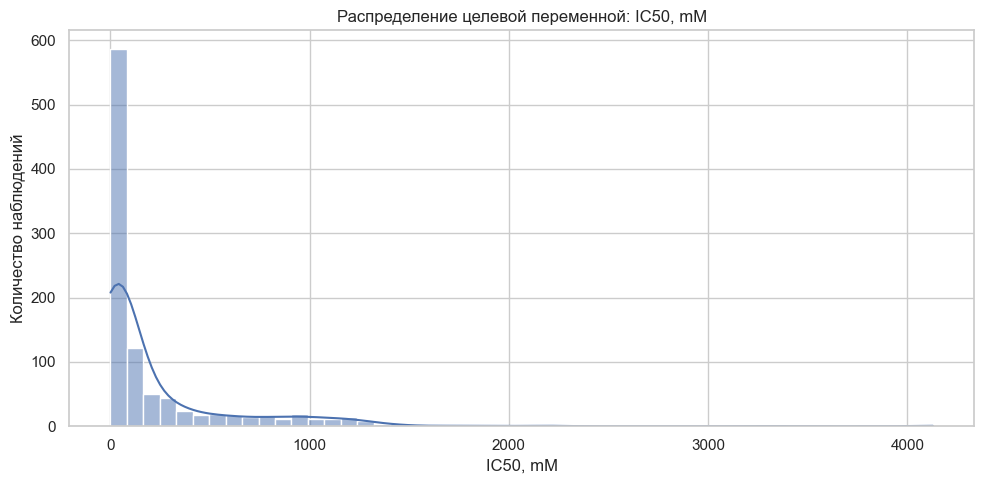

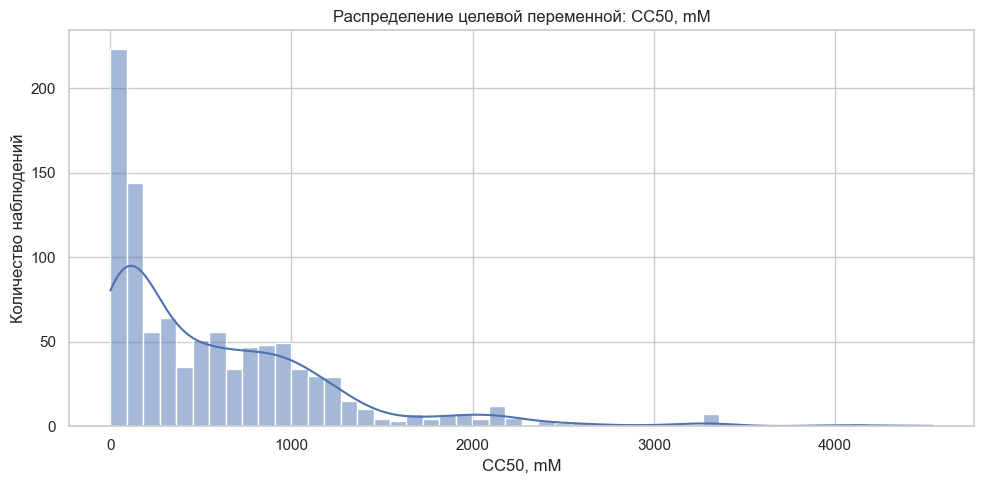

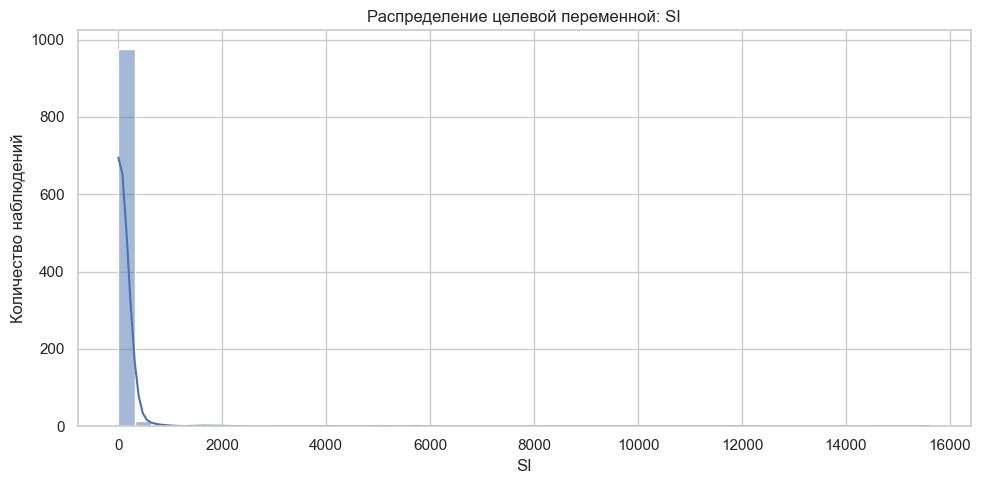

In [203]:
target_columns = [TARGET_IC50, TARGET_CC50, TARGET_SI]

for target_column in target_columns:
    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x=target_column,
        bins=50,
        kde=True,
    )

    plt.title(f"Распределение целевой переменной: {target_column}")
    plt.xlabel(target_column)
    plt.ylabel("Количество наблюдений")
    plt.tight_layout()

    file_name = f"distribution_{target_column.replace(', ', '_').replace(' ', '_').lower()}.png"
    plt.savefig(FIGURES_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()

Теперь логарифмический масштаб.
Так как значения положительные, можно использовать `log1p`.

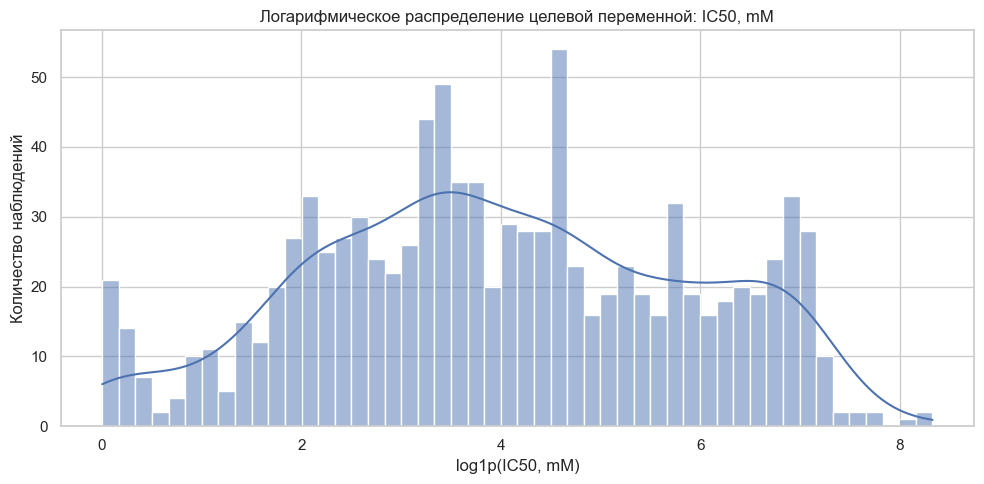

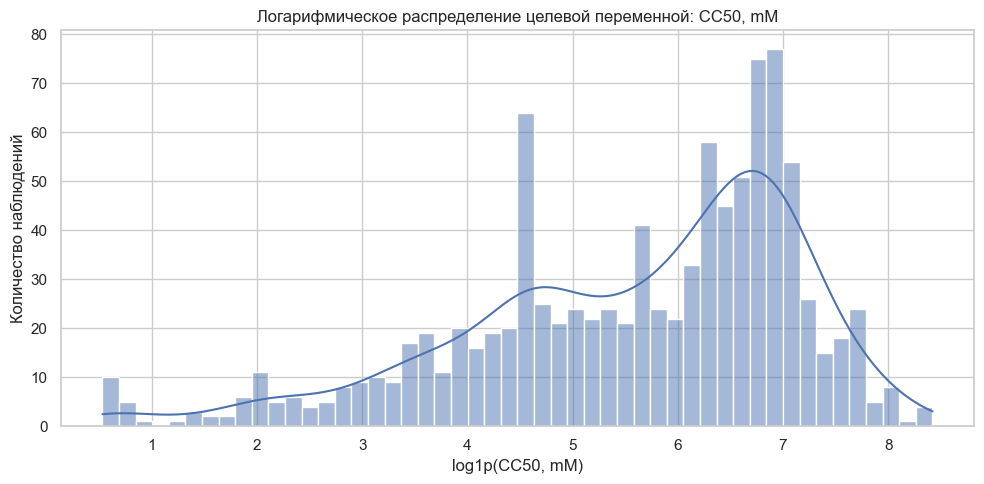

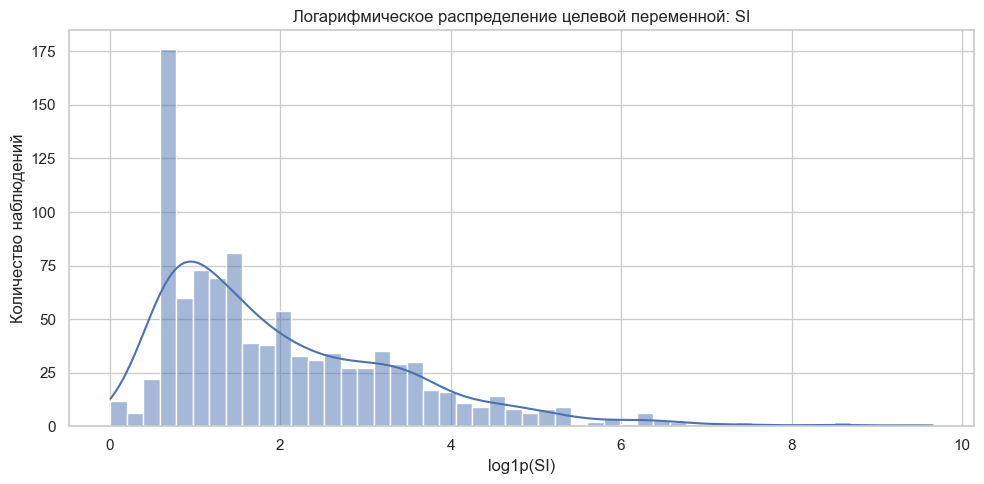

In [204]:
for target_column in target_columns:
    plt.figure(figsize=(10, 5))

    sns.histplot(
        x=np.log1p(df[target_column]),
        bins=50,
        kde=True,
    )

    plt.title(f"Логарифмическое распределение целевой переменной: {target_column}")
    plt.xlabel(f"log1p({target_column})")
    plt.ylabel("Количество наблюдений")
    plt.tight_layout()

    file_name = f"log_distribution_{target_column.replace(', ', '_').replace(' ', '_').lower()}.png"
    plt.savefig(FIGURES_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()

## Анализ выбросов в целевых переменных

Для оценки выбросов построим boxplot-графики по целевым переменным.

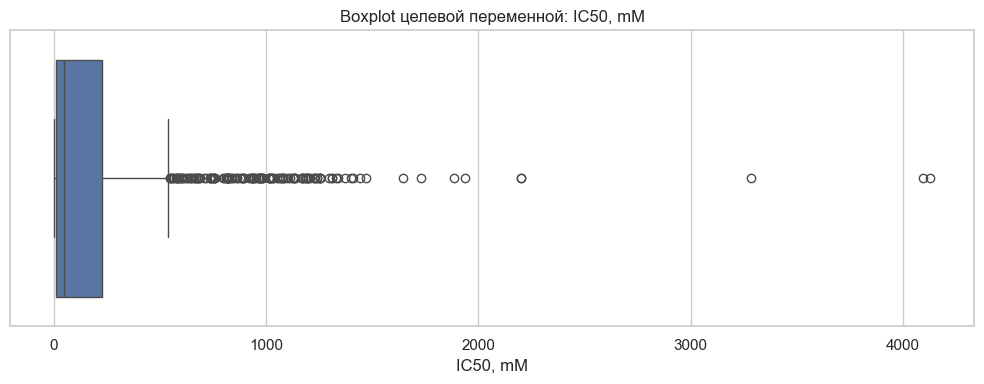

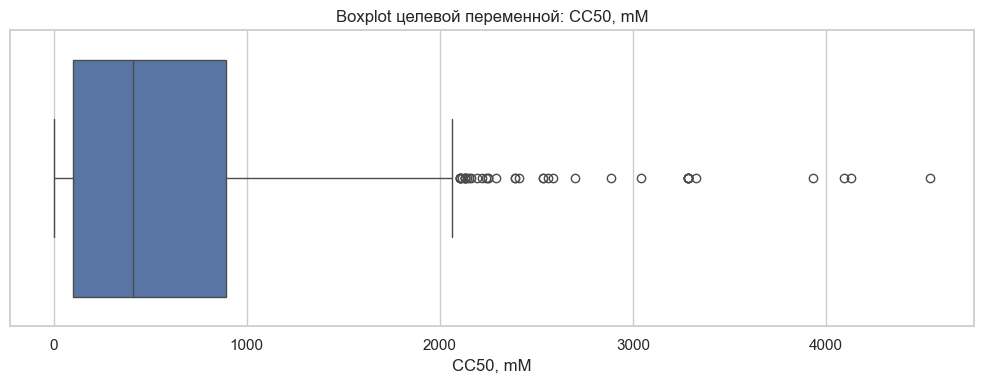

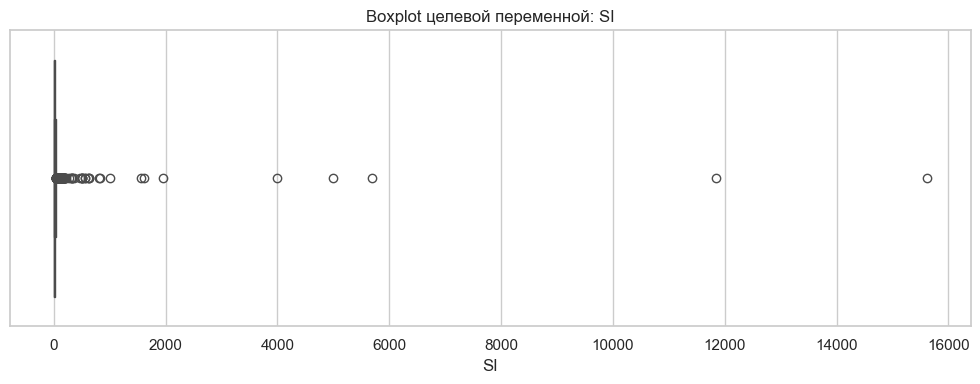

In [205]:
for target_column in target_columns:
    plt.figure(figsize=(10, 4))

    sns.boxplot(
        data=df,
        x=target_column,
    )

    plt.title(f"Boxplot целевой переменной: {target_column}")
    plt.xlabel(target_column)
    plt.tight_layout()

    file_name = f"boxplot_{target_column.replace(', ', '_').replace(' ', '_').lower()}.png"
    plt.savefig(FIGURES_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()

Отдельно построим boxplot в логарифмическом масштабе.

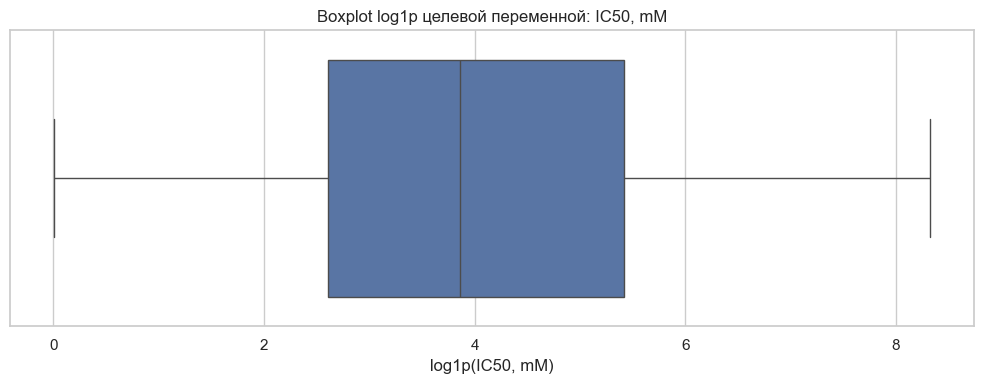

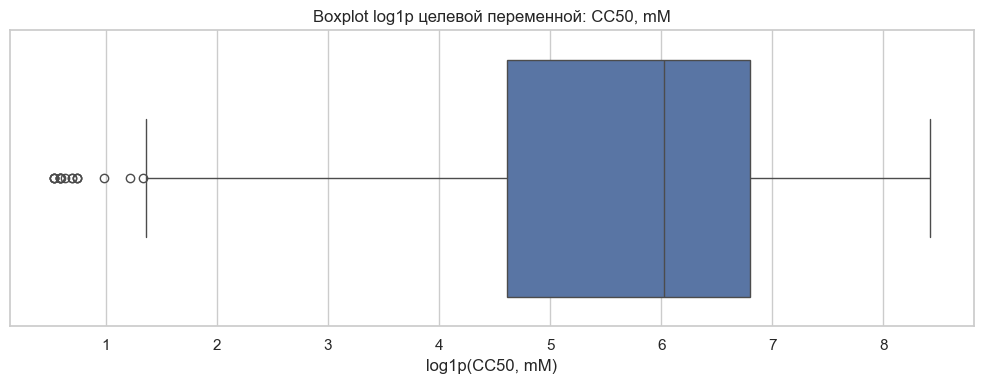

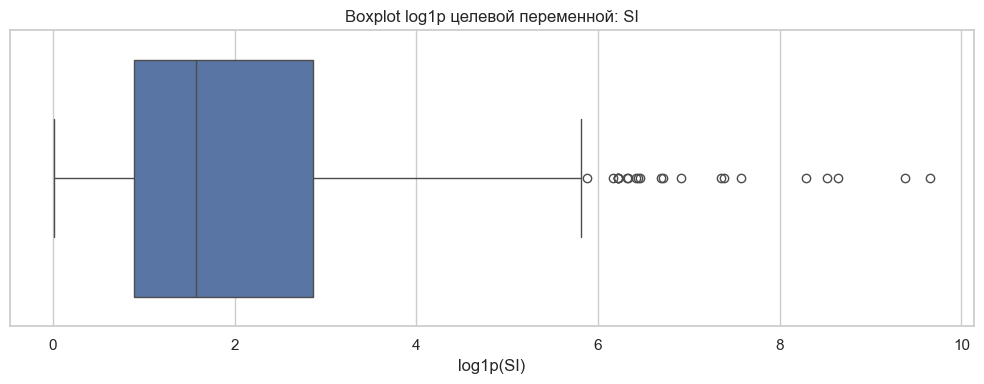

In [206]:
for target_column in target_columns:
    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=np.log1p(df[target_column]),
    )

    plt.title(f"Boxplot log1p целевой переменной: {target_column}")
    plt.xlabel(f"log1p({target_column})")
    plt.tight_layout()

    file_name = f"log_boxplot_{target_column.replace(', ', '_').replace(' ', '_').lower()}.png"
    plt.savefig(FIGURES_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()

## Выводы по распределениям, пропускам и выбросам

В датасете обнаружено небольшое количество пропущенных значений: всего 36 пропусков в 12 столбцах.
Максимальная доля пропусков в одном признаке составляет около 0.30%, поэтому удаление признаков или строк на данном этапе не требуется.
Планируется использовать заполнение пропусков медианным значением внутри, чтобы избежать утечки данных между обучающей и тестовой выборками.

Все признаки в датасете являются числовыми, что упрощает построение моделей классического машинного обучения.
После исключения служебного столбца `Unnamed: 0` и целевых переменных `IC50, mM`, `CC50, mM`, `SI` для обучения остается 210 признаков.

Распределения целевых переменных в исходном масштабе имеют выраженную правостороннюю асимметрию.
Большая часть наблюдений сосредоточена в области сравнительно небольших значений, при этом присутствуют отдельные экстремально большие значения.
Это особенно заметно для `SI`, где основная масса объектов находится близко к малым значениям, но встречаются выбросы вплоть до значений более 15000.

Для более наглядного анализа дополнительно использовался логарифмический масштаб, то есть к значениям применялось преобразование
`log1p(x) = log(1 + x)`.
Такое преобразование сжимает большие значения сильнее, чем малые, и позволяет лучше рассмотреть структуру распределения,
когда данные имеют длинный правый хвост.

Boxplot-графики подтверждают наличие выбросов во всех трех целевых переменных.
В исходном масштабе выбросы особенно сильно выражены у `IC50, mM` и `SI`.
После логарифмического преобразования выбросы становятся менее заметными визуально,
но для `SI` сохраняется группа наблюдений, заметно удаленных от основной массы данных.

Для дальнейшего моделирования планируется следующее:

- в задачах регрессии следует использовать не только `MSE`/`RMSE`, но и `MAE`, так как `MAE` менее чувствительна к экстремальным значениям
- пропущенные значения целесообразно заполнять медианой внутри preprocessing pipeline
- выбросы не следует удалять автоматически, так как в химической задаче экстремальные значения могут отражать интересные соединения
- при построении моделей для `SI` необходимо исключать `IC50, mM` и `CC50, mM` из признаков, чтобы избежать утечки данных

## Корреляции между целевыми переменными

Далее перейдем к оценке взаимосвязи между целевыми переменными `IC50, mM`, `CC50, mM` и `SI`.

Так как распределения целевых переменных имеют выраженную асимметрию и выбросы, попробуем два варианта:

- корреляцию в исходном масштабе
- корреляцию после логарифмического преобразования `log1p`

In [207]:
target_columns = [TARGET_IC50, TARGET_CC50, TARGET_SI]
# Spearman устойчивее к нелинейным монотонным связям и выбросам, чем Pearson,
# поэтому пробуем его
target_corr = df[target_columns].corr(method="spearman")

target_corr

,"IC50, mM","CC50, mM",SI
"IC50, mM",1.0000,0.6214,-0.6428
"CC50, mM",0.6214,1.0000,0.0998
SI,-0.6428,0.0998,1.0000


## Строим график

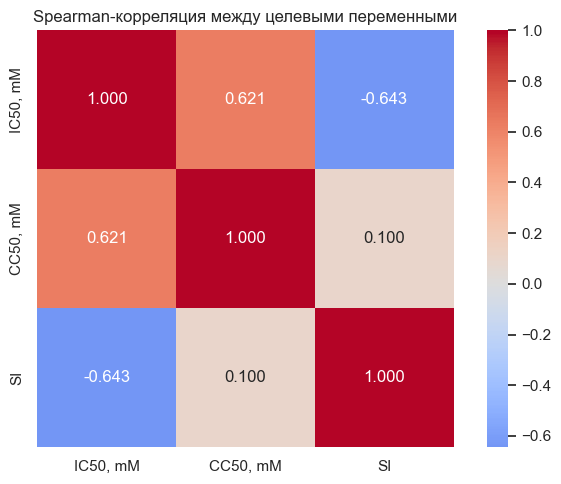

In [208]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    target_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title("Spearman-корреляция между целевыми переменными")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "target_spearman_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

## Корреляция после логарифмического преобразования

Ранее логарифмическое преобразование использовалось для визуального анализа распределений.
Проверим, изменит ли оно ранговые связи между целевыми переменными.

Так как Spearman-корреляция основана на рангах, а `log1p` является монотонным преобразованием,
то предполагаем, что значения корреляций останутся теми же.

In [209]:
log_target_df = np.log1p(df[target_columns])

log_target_corr = log_target_df.corr(method="spearman")

log_target_corr

,"IC50, mM","CC50, mM",SI
"IC50, mM",1.0000,0.6214,-0.6428
"CC50, mM",0.6214,1.0000,0.0998
SI,-0.6428,0.0998,1.0000


## График логарифмического варианта

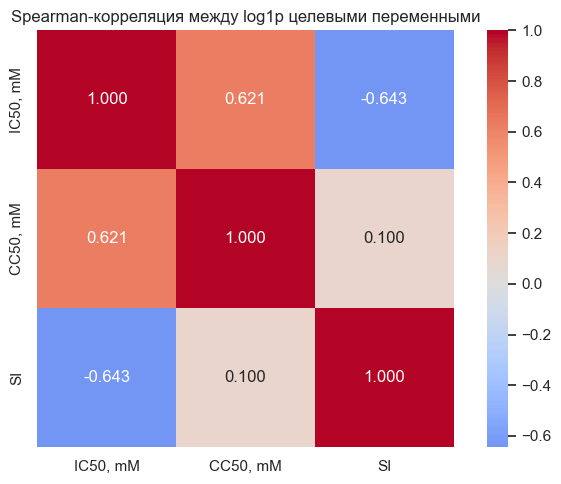

In [210]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    log_target_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title("Spearman-корреляция между log1p целевыми переменными")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "target_log_spearman_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

## Корреляции признаков с целевыми переменными

Для предварительной оценки информативности признаков рассчитаем Spearman-корреляцию каждого признака с целевыми переменными.

Это не является полноценным отбором признаков, так как модели на деревьях могут находить нелинейные зависимости,
однако такой анализ помогает понять, какие дескрипторы потенциально связаны с прогнозируемыми показателями.

In [211]:
features_df = build_features(df)

feature_target_corr = features_df.join(df[target_columns]).corr(method="spearman")

target_feature_corr = (
    feature_target_corr[target_columns]
    .drop(index=target_columns)
    .reset_index()
    .rename(columns={"index": "feature"})
)

target_feature_corr.head()

,feature,"IC50, mM","CC50, mM",SI
0,MaxAbsEStateIndex,0.1121,-0.1070,-0.2009
1,MaxEStateIndex,0.1121,-0.1070,-0.2009
2,MinAbsEStateIndex,-0.0071,0.0740,0.0616
3,MinEStateIndex,-0.1395,0.0386,0.1957
4,qed,0.0663,0.1205,0.0365


## Сделаем функцию для топ-корреляций

In [212]:
def get_top_correlated_features(
    correlation_df: pd.DataFrame,
    target_column: str,
    top_n: int = 15,
) -> pd.DataFrame:
    """
    Получает признаки с наибольшей абсолютной корреляцией с целевой переменной.

    Аргументы:
        - correlation_df: DataFrame с корреляциями признаков и целевых переменных.
        - target_column: Название целевой переменной.
        - top_n: Количество признаков для вывода.

    Возвращает:
        DataFrame с топом признаков по модулю корреляции.
    """
    result = correlation_df[["feature", target_column]].copy()
    result["abs_correlation"] = result[target_column].abs()

    return (
        result
        .sort_values("abs_correlation", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

## Выведем топы

In [213]:
top_corr_ic50 = get_top_correlated_features(target_feature_corr, TARGET_IC50)
top_corr_cc50 = get_top_correlated_features(target_feature_corr, TARGET_CC50)
top_corr_si = get_top_correlated_features(target_feature_corr, TARGET_SI)

top_corr_ic50

,feature,"IC50, mM",abs_correlation
0,NumSaturatedHeterocycles,0.2779,0.2779
1,SlogP_VSA5,-0.2705,0.2705
2,VSA_EState4,-0.2595,0.2595
3,NumAliphaticCarbocycles,-0.2451,0.2451
4,fr_NH2,-0.2430,0.2430
5,VSA_EState8,-0.2386,0.2386
6,PEOE_VSA7,-0.2282,0.2282
7,NumAliphaticHeterocycles,0.2238,0.2238
8,EState_VSA8,-0.2185,0.2185
9,BCUT2D_MWLOW,0.2129,0.2129


In [214]:
top_corr_cc50

,feature,"CC50, mM",abs_correlation
0,Kappa2,-0.3028,0.3028
1,Kappa3,-0.2991,0.2991
2,Kappa1,-0.2930,0.2930
3,MolMR,-0.2831,0.2831
4,Chi1v,-0.2798,0.2798
5,Chi0v,-0.2781,0.2781
6,NumValenceElectrons,-0.2777,0.2777
7,Chi0,-0.2776,0.2776
8,Chi1n,-0.2764,0.2764
9,LabuteASA,-0.2760,0.2760


In [215]:
top_corr_si

,feature,SI,abs_correlation
0,fr_Imine,0.2165,0.2165
1,MaxAbsEStateIndex,-0.2009,0.2009
2,MaxEStateIndex,-0.2009,0.2009
3,NumSaturatedCarbocycles,0.2008,0.2008
4,MinEStateIndex,0.1957,0.1957
5,FractionCSP3,0.1914,0.1914
6,SMR_VSA4,0.1896,0.1896
7,NumAliphaticCarbocycles,0.1888,0.1888
8,NumSaturatedHeterocycles,-0.1837,0.1837
9,VSA_EState8,0.1827,0.1827


## Графики топ-корреляций

In [216]:
def plot_top_correlated_features(
    top_corr_df: pd.DataFrame,
    target_column: str,
    file_name: str,
) -> None:
    """
    Строит график топ-признаков по корреляции с целевой переменной.

    Аргументы:
        - top_corr_df: DataFrame с признаками и корреляциями.
        - target_column: Название целевой переменной.
        - file_name: Имя файла для сохранения графика.
    """
    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=top_corr_df,
        x=target_column,
        y="feature",
    )

    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Топ признаков по Spearman-корреляции с {target_column}")
    plt.xlabel("Spearman-корреляция")
    plt.ylabel("Признак")
    plt.tight_layout()

    plt.savefig(FIGURES_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()

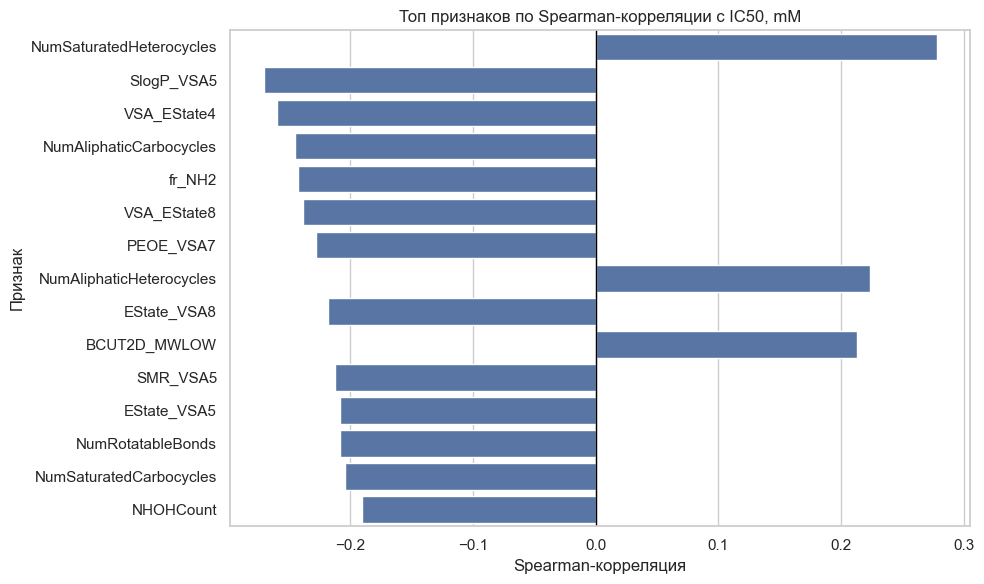

In [217]:
plot_top_correlated_features(
    top_corr_ic50,
    TARGET_IC50,
    "top_features_corr_ic50.png",
)

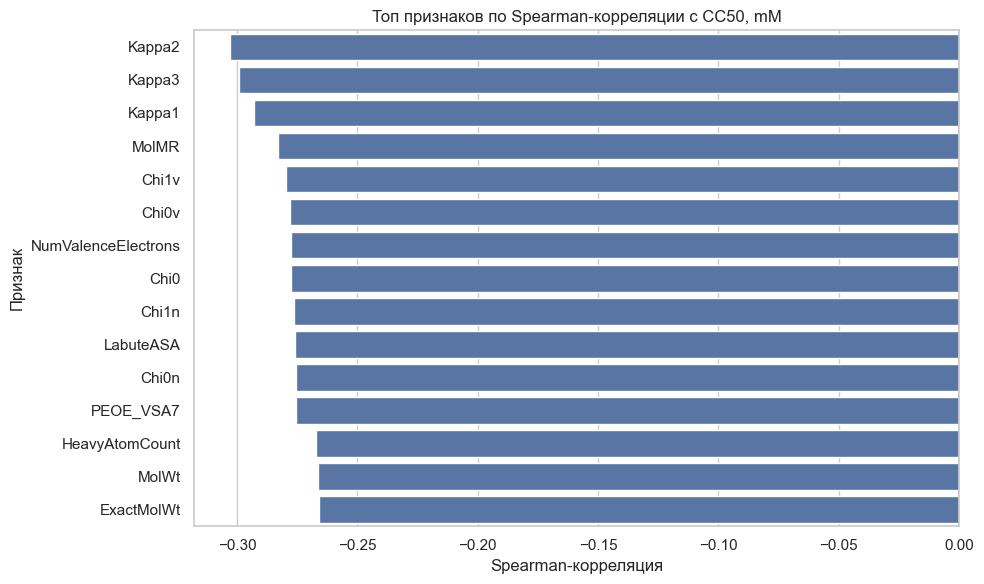

In [218]:
plot_top_correlated_features(
    top_corr_cc50,
    TARGET_CC50,
    "top_features_corr_cc50.png",
)

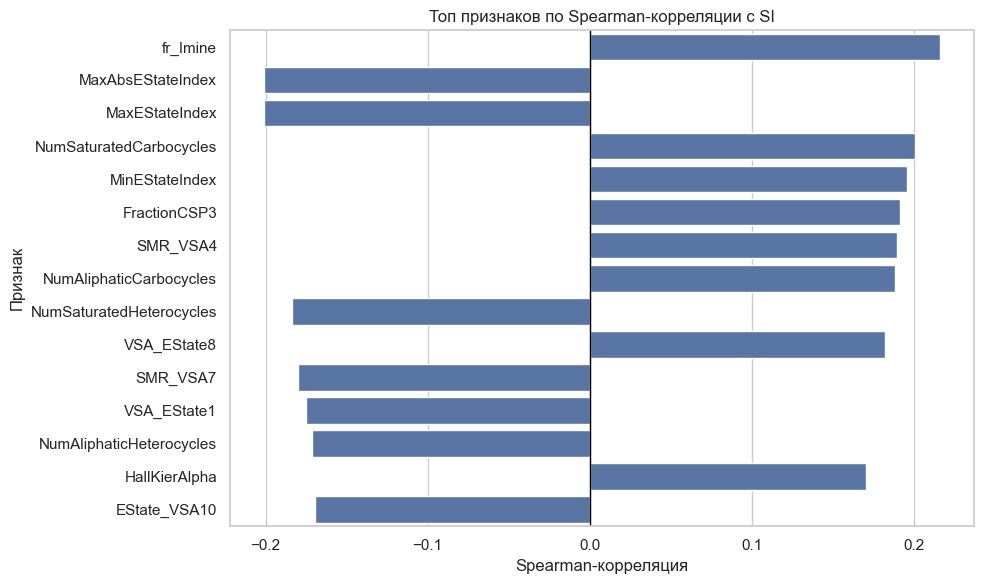

In [219]:
plot_top_correlated_features(
    top_corr_si,
    TARGET_SI,
    "top_features_corr_si.png",
)

## Корреляции между признаками

В датасете содержится большое количество молекулярных дескрипторов.
Часть из них может быть сильно связана между собой, что приводит к избыточности признакового пространства.

Для оценки мультиколлинеарности найдем пары признаков с высокой абсолютной корреляцией.

In [220]:
feature_corr_matrix = features_df.corr(method="spearman").abs()

upper_triangle = feature_corr_matrix.where(
    np.triu(np.ones(feature_corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_spearman_corr"]

high_corr_pairs = (
    high_corr_pairs
    .query("abs_spearman_corr >= 0.9")
    .sort_values("abs_spearman_corr", ascending=False)
    .reset_index(drop=True)
)

high_corr_pairs.head(30)

,feature_1,feature_2,abs_spearman_corr
0,MaxAbsEStateIndex,MaxEStateIndex,1.0000
1,NumAromaticCarbocycles,fr_benzene,1.0000
2,fr_COO,fr_COO2,1.0000
3,fr_Ar_NH,fr_Nhpyrrole,1.0000
4,fr_phenol,fr_phenol_noOrthoHbond,1.0000
5,MolWt,ExactMolWt,1.0000
6,Chi1,HeavyAtomCount,0.9978
7,MolWt,HeavyAtomMolWt,0.9956
8,HeavyAtomMolWt,ExactMolWt,0.9955
9,Chi1,Ipc,0.9942


In [221]:
print(f"Количество пар признаков с |Spearman correlation| >= 0.90: {len(high_corr_pairs)}")

Количество пар признаков с |Spearman correlation| >= 0.90: 136


## Выводы по корреляционному анализу

Для анализа взаимосвязей использовалась Spearman-корреляция.
Этот коэффициент оценивает монотонную связь между переменными и лучше подходит для текущего датасета,
чем Pearson-корреляция, так как целевые переменные имеют выраженную асимметрию и выбросы.

Корреляционный анализ целевых переменных показал следующее:

- между `IC50, mM` и `CC50, mM` наблюдается умеренная положительная связь: `0.6214`;
- между `IC50, mM` и `SI` наблюдается умеренная отрицательная связь: `-0.6428`;
- между `CC50, mM` и `SI` связь слабая: `0.0998`.

Отрицательная связь между `IC50, mM` и `SI` объясняется тем,
что при меньшем значении `IC50` соединение считается более эффективным.
Так как `SI` рассчитывается с учетом `IC50`, то при уменьшении `IC50` значение `SI` обычно увеличивается.

Слабая связь между `CC50, mM` и `SI` говорит о том, что в данной выборке изменение `SI` больше зависит от `IC50`, чем от `CC50`.

Дополнительно была рассчитана Spearman-корреляция после логарифмического преобразования целевых переменных через `log1p`.
Значения корреляций при этом не изменились. Это ожидаемый результат, так как Spearman-корреляция работает не с самими значениями,
а с их рангами.
Логарифмическое преобразование `log1p` является монотонным и сохраняет порядок наблюдений, поэтому ранговые корреляции остаются теми же.
Таким образом, логарифмирование полезно для визуализации распределений и потенциально для обучения регрессионных моделей,
но не меняет Spearman-корреляции.

Анализ корреляций признаков с целевыми переменными показал,
что отдельные признаки имеют только слабую или умеренно слабую связь с целями.

Максимальные абсолютные значения корреляций составили примерно:

- для `IC50, mM`: `0.2779`;
- для `CC50, mM`: `0.3028`;
- для `SI`: `0.2165`.

Это означает, что ни один отдельный молекулярный дескриптор сам по себе не объясняет целевые переменные достаточно хорошо.
Следовательно, для качественного прогноза моделям потребуется использовать комбинации признаков и нелинейные зависимости между ними.

Для `IC50, mM` наиболее связанные признаки включают
`NumSaturatedHeterocycles`, `SlogP_VSA5`, `VSA_EState4`, `NumAliphaticCarbocycles`, `fr_NH2`.
Корреляции при этом находятся примерно в диапазоне до `0.28` по модулю.

Для `CC50, mM` наиболее связанные признаки включают
`Kappa2`, `Kappa3`, `Kappa1`, `MolMR`, `Chi1v`, `Chi0v`, `NumValenceElectrons`.
Большинство топ-признаков имеют отрицательную корреляцию с `CC50, mM`,
а максимальная абсолютная связь составляет около `0.30`.

Для `SI` наиболее связанные признаки включают
`fr_Imine`, `MaxAbsEStateIndex`, `MaxEStateIndex`, `NumSaturatedCarbocycles`, `MinEStateIndex`, `FractionCSP3`.
Связи с `SI` слабее, чем для `IC50, mM` и `CC50, mM`, что предварительно указывает на более сложную задачу прогнозирования `SI`.

Также был проведен анализ корреляций между самими признаками.
В признаковом пространстве обнаружено `136` пар признаков с абсолютной Spearman-корреляцией не ниже `0.90`.

Некоторые признаки фактически дублируют друг друга по ранговой структуре, например:

- `MaxAbsEStateIndex` и `MaxEStateIndex`
- `MolWt` и `ExactMolWt`
- `fr_COO` и `fr_COO2`
- `NumAromaticCarbocycles` и `fr_benzene`

Это говорит о наличии избыточности и мультиколлинеарности в данных.
Для линейных моделей такая структура может снижать устойчивость коэффициентов, поэтому для них будут важны масштабирование и регуляризация.
Для моделей на деревьях высокая корреляция признаков менее критична,
но может увеличивать время обучения и усложнять интерпретацию важности признаков.

В дальнейшем при построении моделей необходимо учитывать риск утечки данных.
Показатель `SI` рассчитывается на основе `IC50, mM` и `CC50, mM`,
поэтому при прогнозировании `SI` нельзя использовать `IC50, mM` и `CC50, mM` как входные признаки.
В текущей подготовке признаков эти целевые столбцы уже исключены из матрицы `X`.

## Анализ константных и почти константных признаков

Некоторые признаки могут иметь одно и то же значение почти для всех объектов.
Такие признаки обычно не несут полезной информации для модели и могут быть удалены на этапе предобработки.

Проверим:

- полностью константные признаки
- признаки с очень низкой вариативностью
- признаки, у которых самое частое значение встречается более чем в 99% наблюдений

In [222]:
features_df = build_features(df)

constant_features = [
    column
    for column in features_df.columns
    if features_df[column].nunique(dropna=False) == 1
]

print(f"Количество константных признаков: {len(constant_features)}")

constant_features

Количество константных признаков: 18


['NumRadicalElectrons',
 'SMR_VSA8',
 'SlogP_VSA9',
 'fr_N_O',
 'fr_SH',
 'fr_azide',
 'fr_barbitur',
 'fr_benzodiazepine',
 'fr_diazo',
 'fr_dihydropyridine',
 'fr_isocyan',
 'fr_isothiocyan',
 'fr_lactam',
 'fr_nitroso',
 'fr_phos_acid',
 'fr_phos_ester',
 'fr_prisulfonamd',
 'fr_thiocyan']

## Теперь почти константные признаки

In [223]:
dominant_value_summary = []

for column in features_df.columns:
    value_counts = features_df[column].value_counts(dropna=False, normalize=True)
    dominant_value_share = value_counts.iloc[0]

    dominant_value_summary.append(
        {
            "feature": column,
            "unique_values": features_df[column].nunique(dropna=False),
            "dominant_value_share": dominant_value_share,
        }
    )

dominant_value_summary = (
    pd.DataFrame(dominant_value_summary)
    .sort_values("dominant_value_share", ascending=False)
    .reset_index(drop=True)
)

dominant_value_summary.head(20)

,feature,unique_values,dominant_value_share
0,fr_dihydropyridine,1,1.0000
1,fr_azide,1,1.0000
2,fr_isothiocyan,1,1.0000
3,fr_nitroso,1,1.0000
4,fr_isocyan,1,1.0000
5,SlogP_VSA9,1,1.0000
6,fr_phos_acid,1,1.0000
7,fr_phos_ester,1,1.0000
8,fr_SH,1,1.0000
9,fr_N_O,1,1.0000


## Выведем признаки, где одно значение встречается минимум в 99% строк

In [224]:
near_constant_features = dominant_value_summary.query(
    "dominant_value_share >= 0.99 and unique_values > 1"
).reset_index(drop=True)

print(f"Количество почти константных признаков: {near_constant_features.shape[0]}")

near_constant_features

Количество почти константных признаков: 15


,feature,unique_values,dominant_value_share
0,fr_term_acetylene,2,0.9990
1,fr_Ar_COO,2,0.9990
2,fr_HOCCN,2,0.9990
3,fr_tetrazole,2,0.9990
4,fr_aldehyde,2,0.9970
5,fr_hdrzine,2,0.9970
6,fr_guanido,2,0.9960
7,fr_epoxide,3,0.9960
8,fr_oxazole,2,0.9960
9,fr_nitrile,2,0.9940


## Выведем график для топа признаков с максимальной долей доминирующего значения

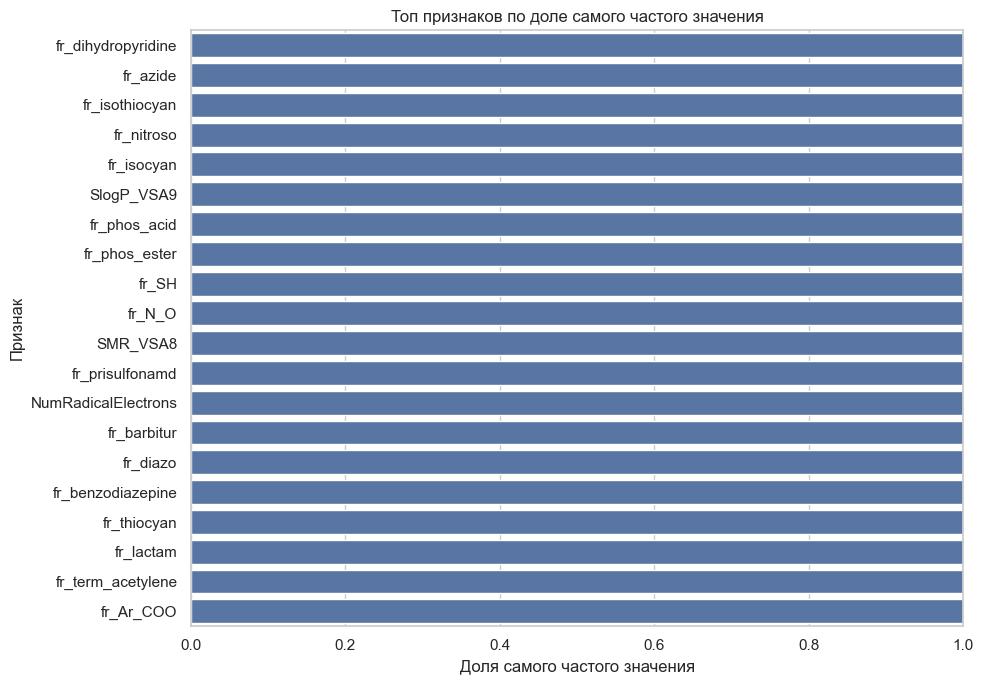

In [225]:
top_dominant_features = dominant_value_summary.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_dominant_features,
    x="dominant_value_share",
    y="feature",
)

plt.title("Топ признаков по доле самого частого значения")
plt.xlabel("Доля самого частого значения")
plt.ylabel("Признак")
plt.xlim(0, 1)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_dominant_value_features.png", dpi=300, bbox_inches="tight")
plt.show()

## Анализ признаков с большим количеством нулевых значений

Часть признаков описывает наличие определенных химических фрагментов.
Для таких признаков большое количество нулей является ожидаемым, так как конкретный фрагмент может отсутствовать у большинства соединений.

Оценим признаки, в которых значение `0` встречается чаще всего.

In [226]:
zero_value_summary = []

for column in features_df.columns:
    zero_share = (features_df[column] == 0).mean()

    zero_value_summary.append(
        {
            "feature": column,
            "zero_share": zero_share,
            "non_zero_share": 1 - zero_share,
        }
    )

zero_value_summary = (
    pd.DataFrame(zero_value_summary)
    .sort_values("zero_share", ascending=False)
    .reset_index(drop=True)
)

zero_value_summary.head(20)

,feature,zero_share,non_zero_share
0,fr_prisulfonamd,1.0000,0.0000
1,fr_phos_ester,1.0000,0.0000
2,fr_isocyan,1.0000,0.0000
3,SlogP_VSA9,1.0000,0.0000
4,fr_phos_acid,1.0000,0.0000
5,fr_benzodiazepine,1.0000,0.0000
6,SMR_VSA8,1.0000,0.0000
7,fr_barbitur,1.0000,0.0000
8,NumRadicalElectrons,1.0000,0.0000
9,fr_dihydropyridine,1.0000,0.0000


## Построим график для наглядности

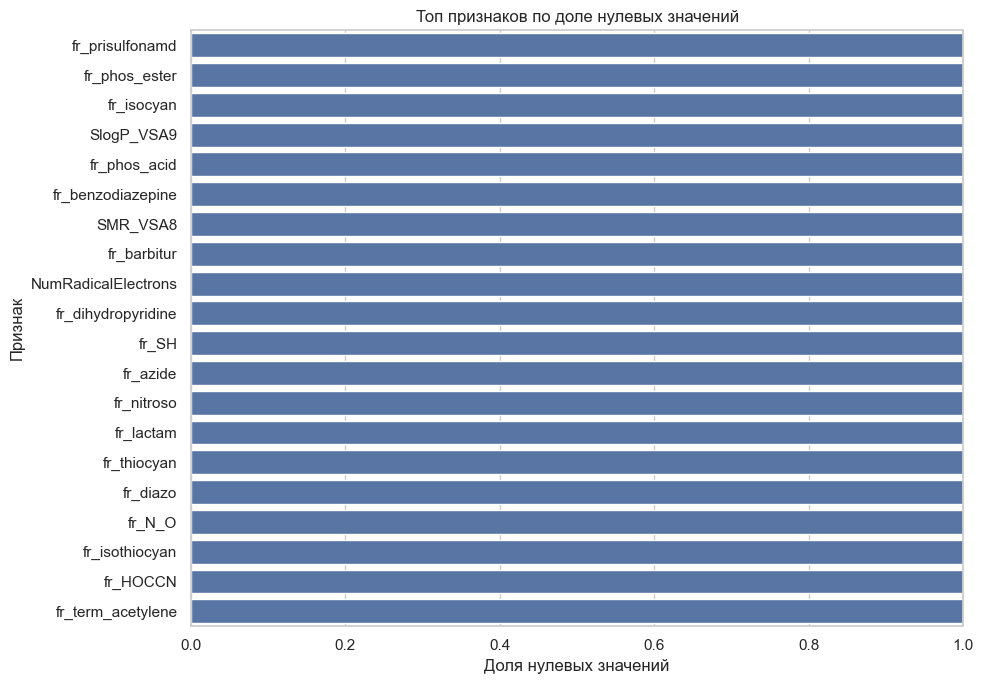

In [227]:
top_zero_features = zero_value_summary.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_zero_features,
    x="zero_share",
    y="feature",
)

plt.title("Топ признаков по доле нулевых значений")
plt.xlabel("Доля нулевых значений")
plt.ylabel("Признак")
plt.xlim(0, 1)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_zero_value_features.png", dpi=300, bbox_inches="tight")
plt.show()

## Выводы по константным и почти константным признакам

В ходе анализа признакового пространства были обнаружены признаки с очень низкой вариативностью.
Полностью константными оказались 18 признаков.
Такие признаки имеют одно и то же значение для всех объектов выборки, поэтому не несут информации для моделей машинного обучения.
Их можно удалить на этапе предобработки без потери полезной информации.

Также было найдено 15 почти константных признаков, у которых одно значение встречается минимум в 99% строк.
Такие признаки формально не являются полностью константными, но их вариативность крайне мала.
В большинстве случаев они также дают модели мало полезной информации, особенно если редкое значение встречается только у нескольких объектов.

Отдельно был проведен анализ признаков с большим количеством нулевых значений.
Для химических фрагментных признаков большое количество нулей является ожидаемым,
ноль означает отсутствие конкретного фрагмента в соединении,
однако, в таком случае его вклад в обучение модели будет минимальным.

По результатам анализа планируется следующее:

- полностью константные признаки необходимо исключить из признакового пространства
- почти константные признаки можно также исключить или оставить удаление на автоматический этап preprocessing
- для дальнейшего моделирования целесообразно использовать `VarianceThreshold`, чтобы автоматически удалять признаки с нулевой или почти нулевой дисперсией внутри пайплайна.

Такой подход позволит уменьшить размерность признакового пространства,
убрать заведомо бесполезные признаки и немного ускорить обучение моделей.

# Итоговые выводы по EDA

В ходе разведочного анализа был изучен датасет химических соединений, содержащий 1001 наблюдение и 214 столбцов.
Из них 3 столбца являются целевыми переменными: `IC50, mM`, `CC50, mM` и `SI`,
один столбец является служебным индексом, а остальные столбцы представляют собой числовые молекулярные дескрипторы.

Все признаки в датасете являются числовыми, что позволяет использовать стандартные алгоритмы классического машинного обучения
без дополнительного кодирования категориальных переменных.

В данных обнаружено небольшое количество пропущенных значений: 36 пропусков в 12 столбцах.
Максимальная доля пропусков в одном признаке составляет около 0.3%,
поэтому удаление строк или признаков только на основании пропусков не требуется.
Для дальнейшего моделирования целесообразно использовать заполнение пропусков медианой внутри `Pipeline`.

Анализ распределений показал, что целевые переменные имеют выраженную правостороннюю асимметрию и выбросы.
Особенно сильно это проявляется для показателя `SI`, у которого встречаются экстремально большие значения.
Логарифмическое преобразование `log1p` позволило лучше рассмотреть структуру распределений и уменьшить визуальное влияние выбросов.

Корреляционный анализ показал, что между `IC50, mM` и `SI` есть заметная отрицательная связь,
а между `IC50, mM` и `CC50, mM` наблюдается умеренная положительная связь.
При этом связь между `CC50, mM` и `SI` слабая.
Это говорит о том, что порядок значений `SI` в выборке сильнее связан с изменением `IC50`, чем с изменением `CC50`.

Отдельные молекулярные дескрипторы имеют только слабую или умеренно слабую корреляцию с целевыми переменными.
Максимальные абсолютные корреляции признаков с целями не превышают примерно 0.3.
Это означает, что для качественного прогноза потребуется использовать комбинации признаков и нелинейные модели.

В признаковом пространстве обнаружены сильно коррелирующие признаки: 136 пар признаков имеют абсолютную Spearman-корреляцию не ниже 0.9.
Это говорит о наличии избыточности и мультиколлинеарности.
Для линейных моделей потребуется регуляризация, а для моделей на деревьях такая проблема менее критична,
хотя может влиять на скорость обучения и интерпретацию важности признаков.

Также были обнаружены признаки с низкой вариативностью.
Полностью константными оказались 18 признаков, а еще 15 признаков являются почти константными: одно значение встречается минимум в 99% строк.
Такие признаки не несут значимой информации для моделей, поэтому их целесообразно удалять на этапе предобработки.

Важно учитывать риск утечки данных.
Показатель `SI` рассчитывается на основе `IC50, mM` и `CC50, mM`,
поэтому при прогнозировании `SI` нельзя использовать `IC50, mM` и `CC50, mM` как признаки.
В подготовленной логике формирования признаков все целевые переменные исключаются из матрицы `X`.

На основании EDA для дальнейшей работы выбрана следующая стратегия:

- использовать молекулярные дескрипторы как признаковое пространство
- исключать служебные и целевые столбцы из признаков
- заполнять пропуски медианой внутри `Pipeline`
- удалять константные и почти константные признаки с помощью `VarianceThreshold`
- использовать масштабирование для линейных моделей
- использовать регуляризацию для линейных моделей из-за мультиколлинеарности признаков
- сравнивать несколько типов моделей: линейные модели, ансамбли деревьев и градиентный бустинг
- оценивать регрессию по `MAE`, `RMSE`, `R2`
- оценивать классификацию по `accuracy`, `precision`, `recall`, `f1`, `roc_auc`
- не удалять выбросы автоматически, так как они могут отражать химически значимые соединения